# 🕵️‍♂️ Post-Processing Data Analysis 

A mandatory check to evaluate if our processing logic drastically skewed or fundamentally misrepresented the underlying datasets prior to committing to model building.

Key checks:
1. **ESA**: Target variable shape unchanged; PCA variance representation.
2. **Rural**: Binned Target distribution vs continuous distribution; scaled feature consistency.
3. **SRDB**: Impacts of `MAT`/`MAP` imputation via biome median; impact of filtering on `Rs_annual`.

In [ ]:
import sys
from pathlib import Path

# Attach project root config path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

raw_dir = Path('../data/raw')
proc_dir = Path('../data/processed')

sns.set_theme(style='whitegrid')

## 1. Module 1: ESA Remote Sensing (SOC)

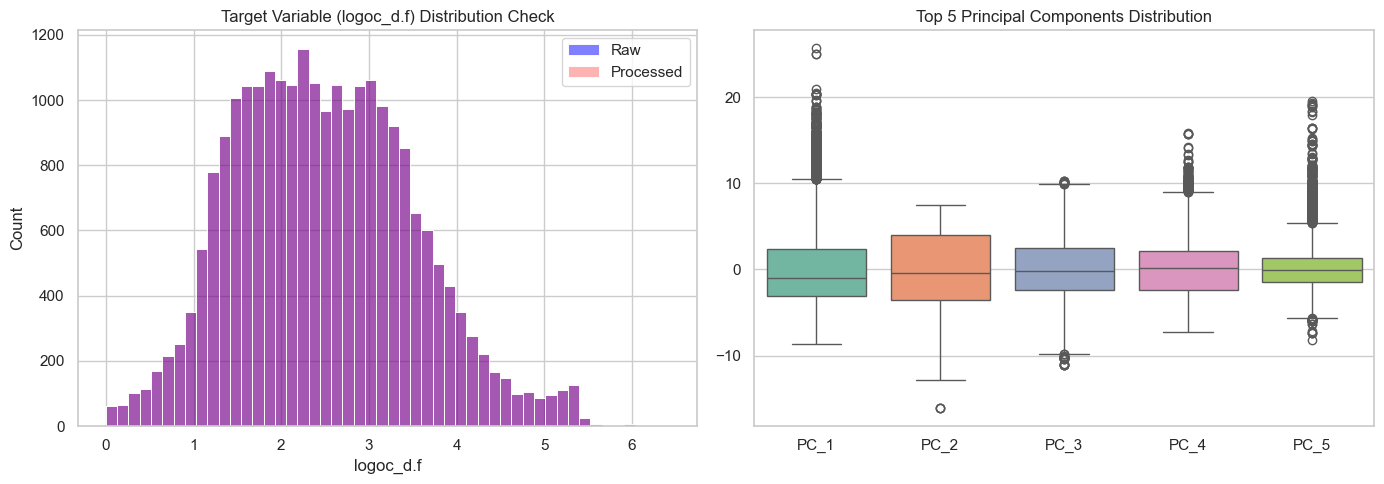

Target parity checked: True


In [2]:
esa_raw = pd.read_csv(raw_dir / 'esa_eo4_train_soc.csv')
esa_proc = pd.read_csv(proc_dir / 'esa_train_processed.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Check target (logoc_d.f) was carried over identically
sns.histplot(esa_raw['logoc_d.f'], bins=50, ax=axes[0], color='blue', alpha=0.5, label='Raw')
sns.histplot(esa_proc['logoc_d.f'], bins=50, ax=axes[0], color='red', alpha=0.3, label='Processed')
axes[0].set_title('Target Variable (logoc_d.f) Distribution Check')
axes[0].legend()

# PCA overview
pc_cols = [c for c in esa_proc.columns if 'PC_' in c]
sns.boxplot(data=esa_proc[pc_cols[:5]], ax=axes[1], palette='Set2')
axes[1].set_title('Top 5 Principal Components Distribution')

plt.tight_layout()
plt.show()

print("Target parity checked:", np.allclose(esa_raw['logoc_d.f'].values, esa_proc['logoc_d.f'].values))

## 2. Module 2: Rural Carbon (Risk Classification)

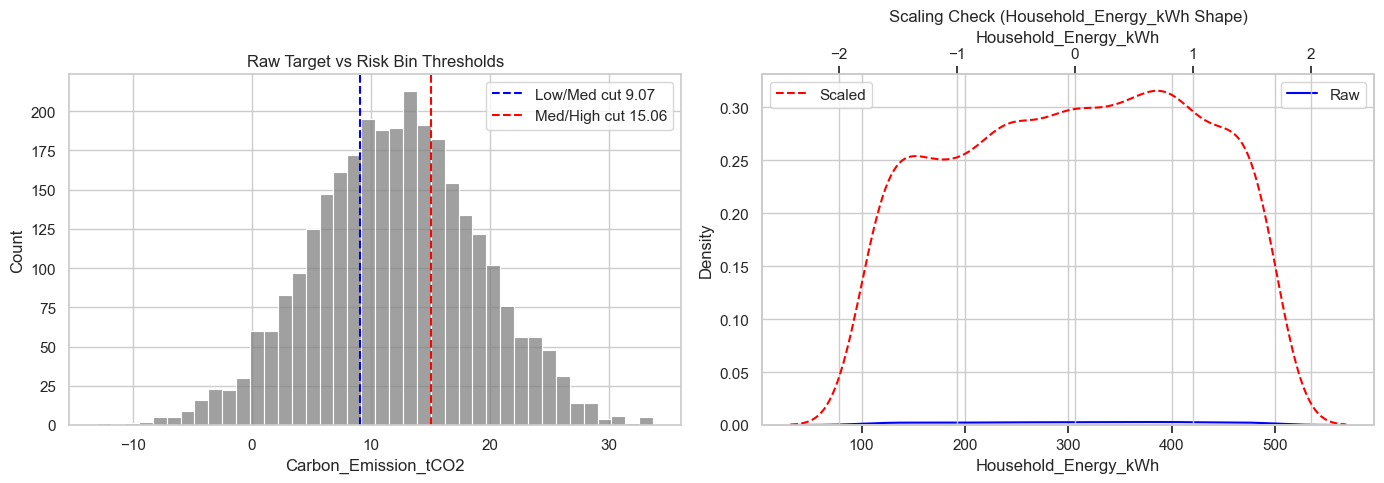

In [3]:
rural_raw = pd.read_csv(raw_dir / 'rural_carbon_dataset1.csv')
rural_proc = pd.read_csv(proc_dir / 'rural_carbon_processed.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# How binning looks over the continuous target
sns.histplot(data=rural_raw, x='Carbon_Emission_tCO2', ax=axes[0], bins=40, color='gray')
# We don't have the original continuous target in processed, but we have target Risk label
# We'll map the raw target into the identical bins generated to show where the splits hit
quantiles = rural_raw['Carbon_Emission_tCO2'].quantile([1/3, 2/3]).values
axes[0].axvline(quantiles[0], color='blue', linestyle='--', label=f'Low/Med cut {quantiles[0]:.2f}')
axes[0].axvline(quantiles[1], color='red', linestyle='--', label=f'Med/High cut {quantiles[1]:.2f}')
axes[0].set_title('Raw Target vs Risk Bin Thresholds')
axes[0].legend()

# Was the feature shape preserved during normalisation? (Household Energy)
sns.kdeplot(rural_raw['Household_Energy_kWh'], label='Raw', ax=axes[1], color='blue')
ax2 = axes[1].twiny() # overlay scaled
sns.kdeplot(rural_proc['Household_Energy_kWh'], label='Scaled', ax=ax2, color='red', ls='--')
axes[1].set_title('Scaling Check (Household_Energy_kWh Shape)')
axes[1].legend(loc='upper right')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 3. Module 3: SRDB Temporal (Imputation impacts)

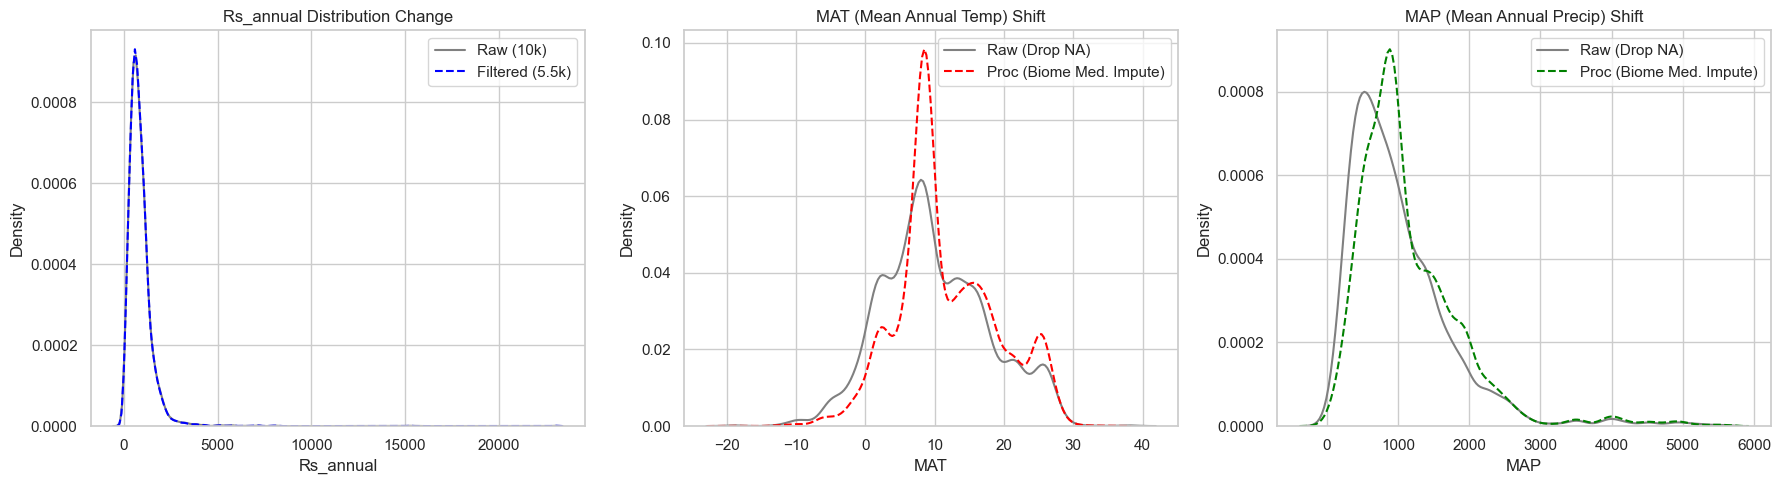

Missing before: MAT=2930, MAP=2241
Missing after: MAT=0, MAP=0


In [4]:
srdb_raw = pd.read_csv(raw_dir / 'srdb-data-V5.csv', low_memory=False)
srdb_proc = pd.read_csv(proc_dir / 'srdb_temporal_processed.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(srdb_raw['Rs_annual'].dropna(), label='Raw (10k)', color='gray', ax=axes[0])
sns.kdeplot(srdb_proc['Rs_annual'], label='Filtered (5.5k)', color='blue', ls='--', ax=axes[0])
axes[0].set_title('Rs_annual Distribution Change')
axes[0].legend()

sns.kdeplot(srdb_raw['MAT'].dropna(), label='Raw (Drop NA)', color='gray', ax=axes[1])
sns.kdeplot(srdb_proc['MAT'], label='Proc (Biome Med. Impute)', color='red', ls='--', ax=axes[1])
axes[1].set_title('MAT (Mean Annual Temp) Shift')
axes[1].legend()

sns.kdeplot(srdb_raw['MAP'].dropna(), label='Raw (Drop NA)', color='gray', ax=axes[2])
sns.kdeplot(srdb_proc['MAP'], label='Proc (Biome Med. Impute)', color='green', ls='--', ax=axes[2])
axes[2].set_title('MAP (Mean Annual Precip) Shift')
axes[2].legend()

plt.tight_layout()
plt.show()

missing_pre = srdb_raw[['MAT', 'MAP']].isna().sum().to_dict()
print(f"Missing before: MAT={missing_pre['MAT']}, MAP={missing_pre['MAP']}")
missing_post = srdb_proc[['MAT', 'MAP']].isna().sum().to_dict()
print(f"Missing after: MAT={missing_post['MAT']}, MAP={missing_post['MAP']}")